# **Libraries** 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings("ignore")

# **Read / Understand Dataset**

Load data

In [2]:
data = pd.read_csv("D:\\Diabetes\\Dataset\\diabetes.csv")

Read first 5 rows

In [3]:
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,2,138,62,35,0,33.6,0.127,47,1
1,0,84,82,31,125,38.2,0.233,23,0
2,0,145,0,0,0,44.2,0.630,31,1
3,0,135,68,42,250,42.3,0.365,24,1
4,1,139,62,41,480,40.7,0.536,21,0


Information about data

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               2000 non-null   int64  
 1   Glucose                   2000 non-null   int64  
 2   BloodPressure             2000 non-null   int64  
 3   SkinThickness             2000 non-null   int64  
 4   Insulin                   2000 non-null   int64  
 5   BMI                       2000 non-null   float64
 6   DiabetesPedigreeFunction  2000 non-null   float64
 7   Age                       2000 non-null   int64  
 8   Outcome                   2000 non-null   int64  
dtypes: float64(2), int64(7)
memory usage: 140.8 KB


Check for unbalance

In [5]:
data["Outcome"].value_counts()

Outcome
0    1316
1     684
Name: count, dtype: int64

Data description

In [6]:
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,3.703500,121.182500,69.145500,20.935000,80.254000,32.193000,0.470930,33.090500,0.342000
std,3.306063,32.068636,19.188315,16.103243,111.180534,8.149901,0.323553,11.786423,0.474498
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,63.500000,0.000000,0.000000,27.375000,0.244000,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,40.000000,32.300000,0.376000,29.000000,0.000000
75%,6.000000,141.000000,80.000000,32.000000,130.000000,36.800000,0.624000,40.000000,1.000000
max,17.000000,199.000000,122.000000,110.000000,744.000000,80.600000,2.420000,81.000000,1.000000


Check for duplicaties

In [7]:
data.duplicated().sum()

np.int64(1256)

In [8]:
data.drop_duplicates(inplace=True)

<Axes: xlabel='Outcome'>

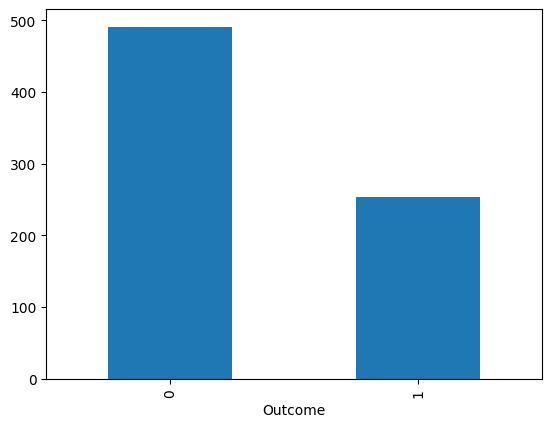

In [9]:
data["Outcome"].value_counts().plot(kind="bar")

Check for null

In [10]:
data.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

# **Visualization**

Histogram

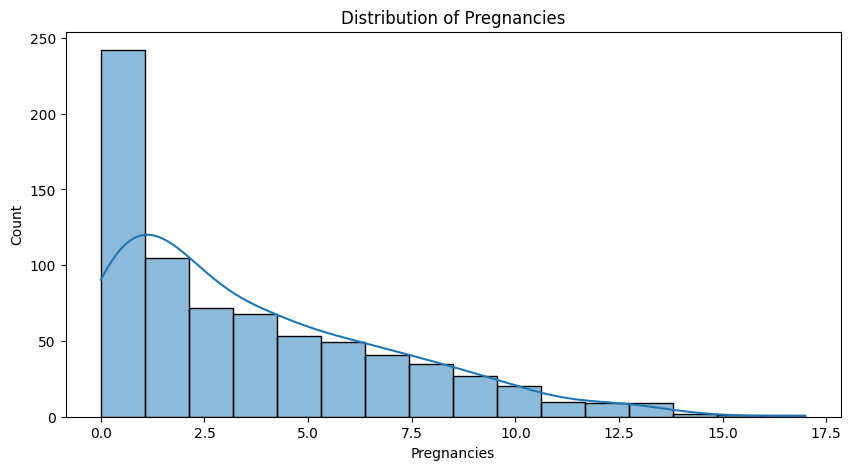

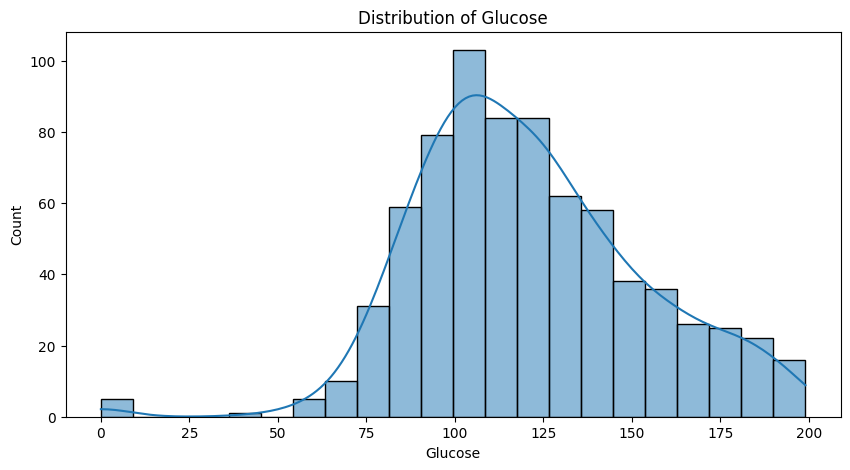

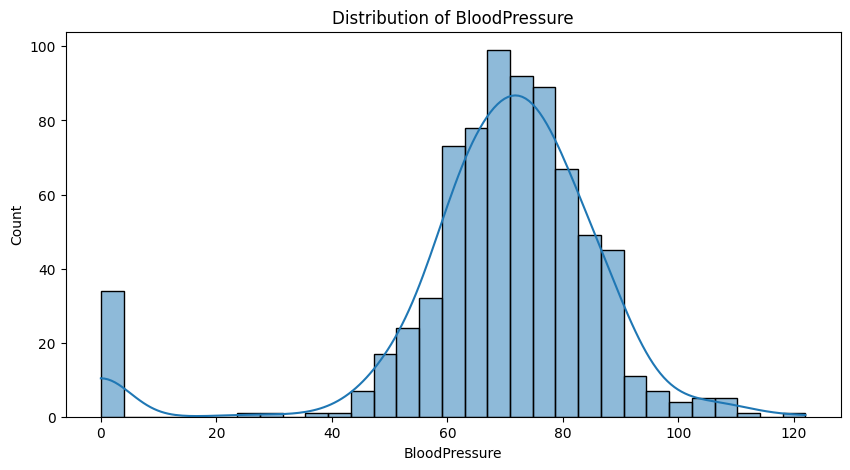

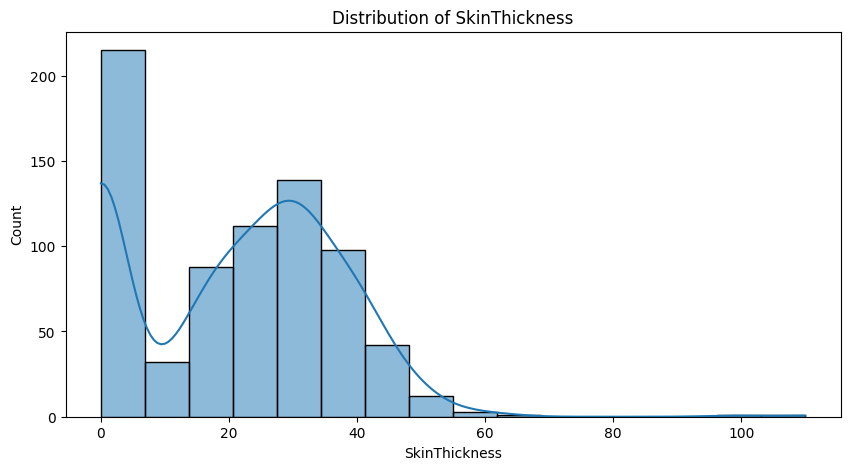

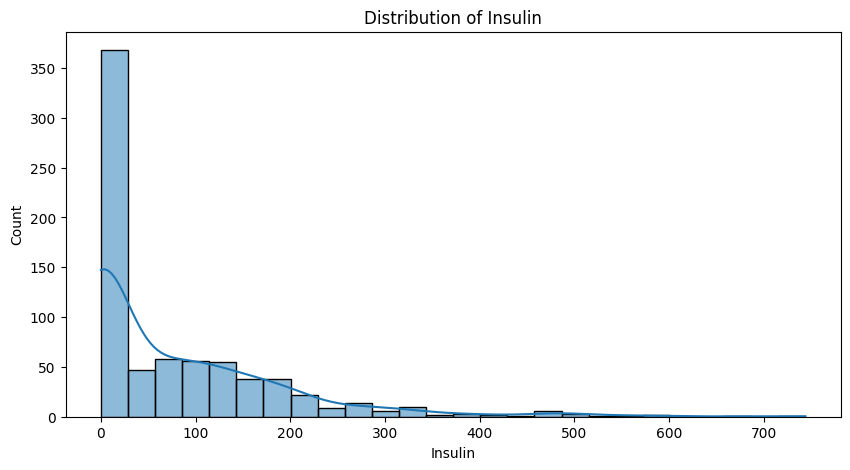

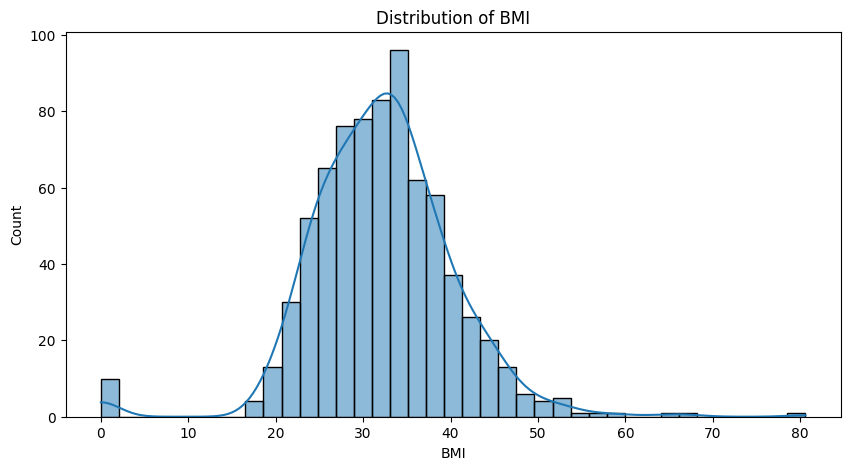

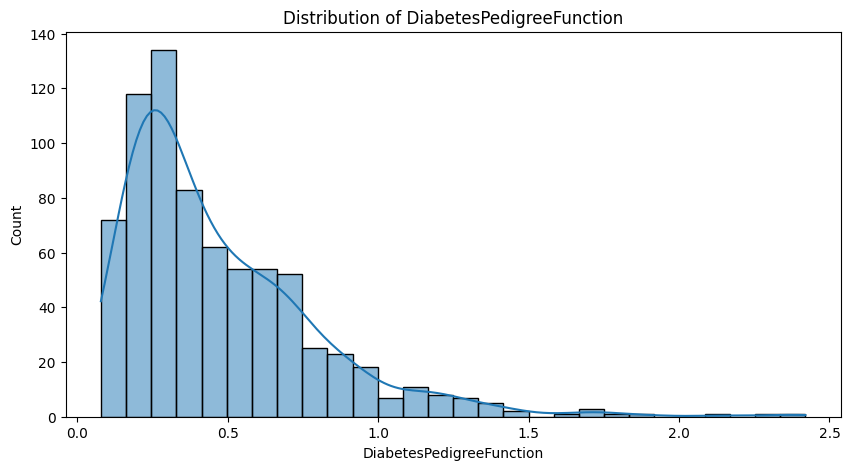

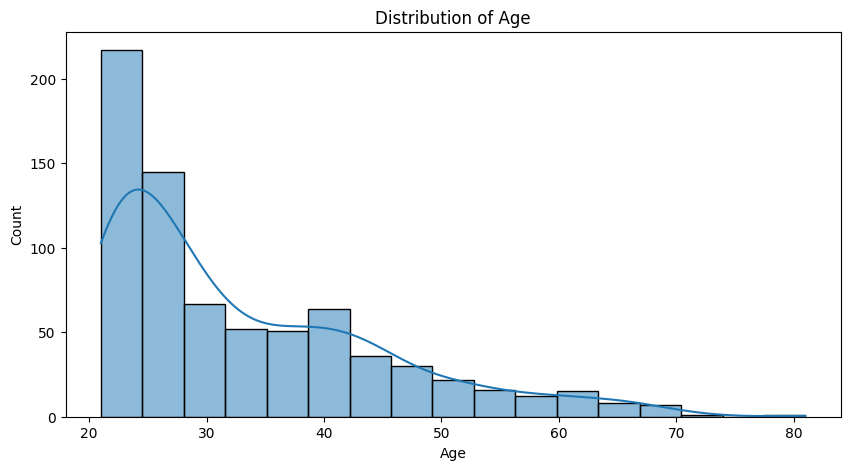

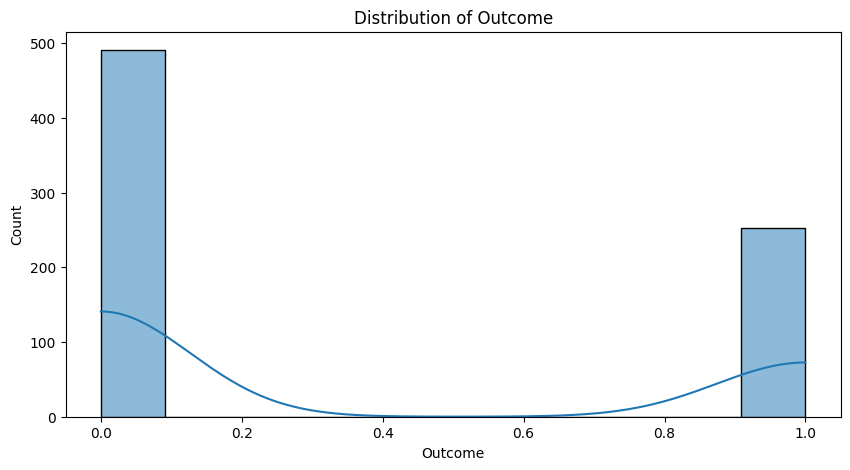

In [11]:
for column in data.columns:
    plt.figure(figsize=(10, 5))
    sns.histplot(data[column], kde=True)
    plt.title(f"Distribution of {column}")
    plt.show()

visulalize the target

Text(0.5, 1.0, 'Count of Diabetic vs Non-Diabetic Cases')

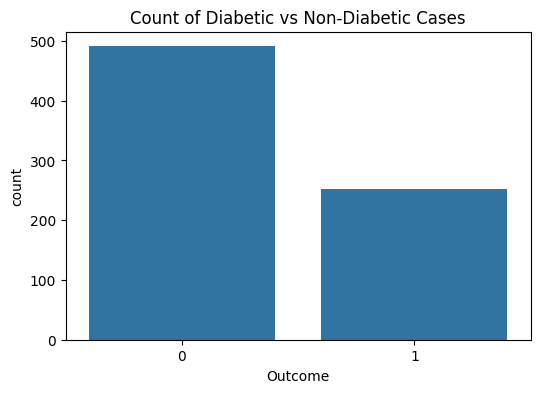

In [12]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Outcome', data=data)
plt.title("Count of Diabetic vs Non-Diabetic Cases")

# **Preprocess data**

Apply standardization

In [13]:
from sklearn.preprocessing import StandardScaler

# Columns to standardize
cols_to_scale = [
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI',
    'DiabetesPedigreeFunction',
    'Age',
    'Pregnancies'
]

# Create scaler
scaler = StandardScaler()

# Apply standardization
data[cols_to_scale] = scaler.fit_transform(data[cols_to_scale])

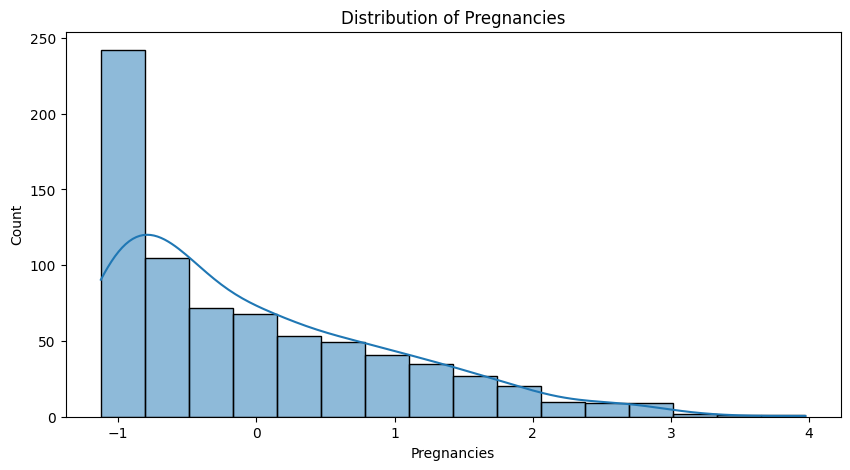

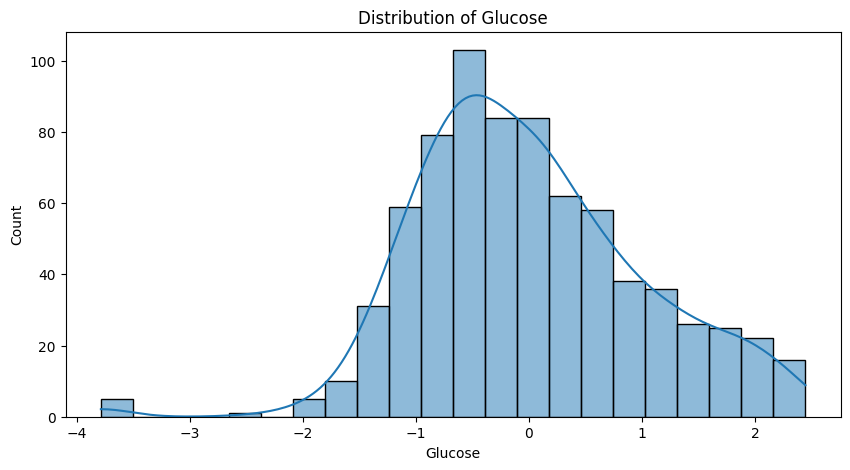

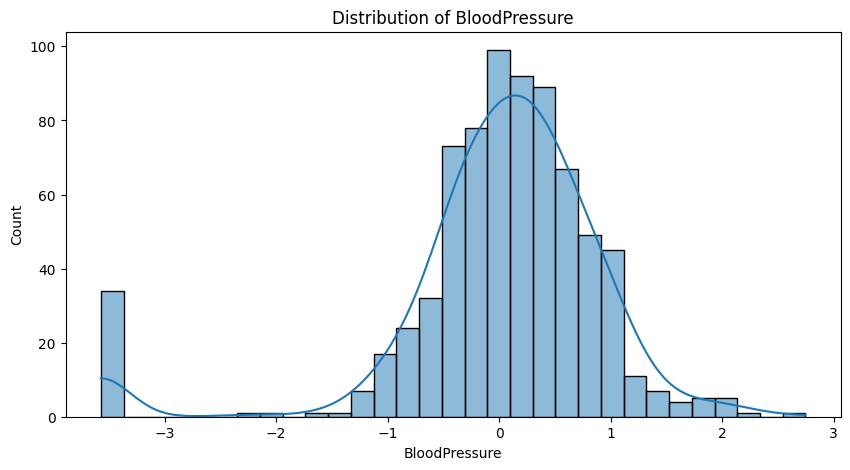

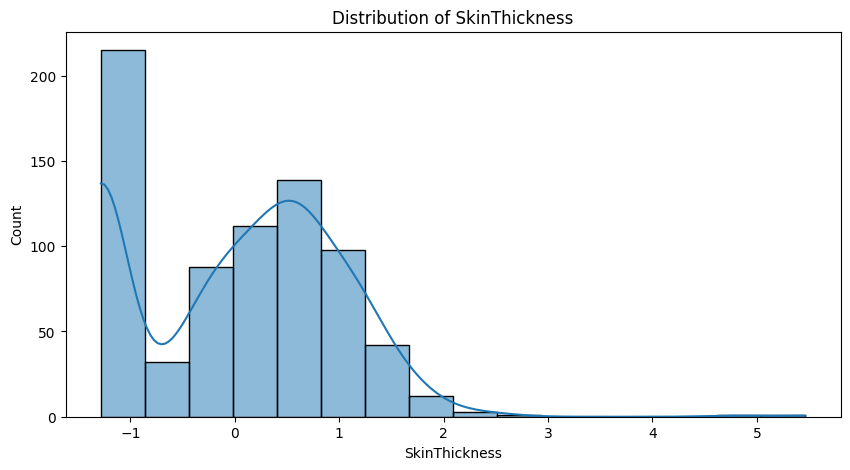

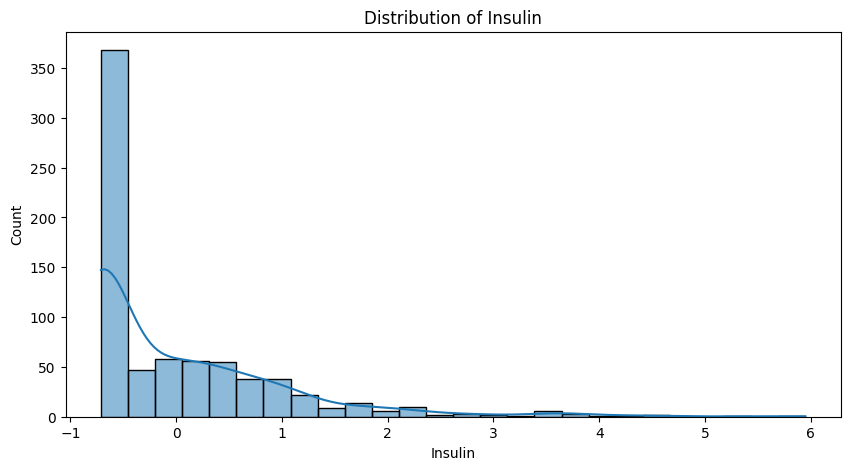

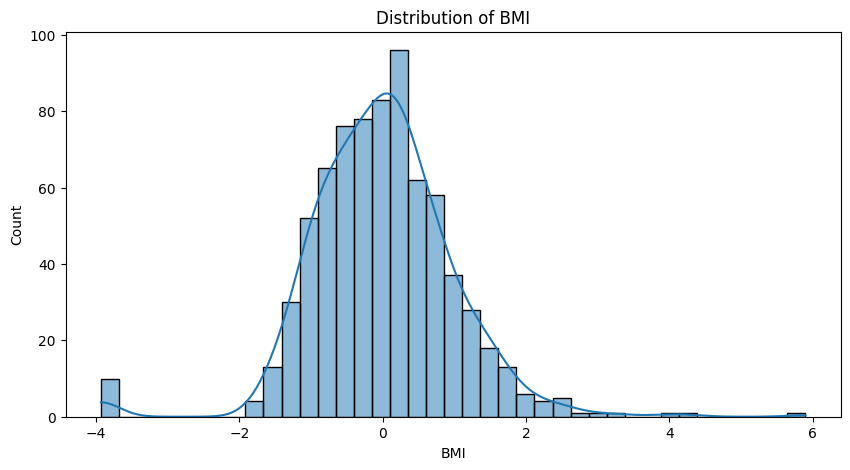

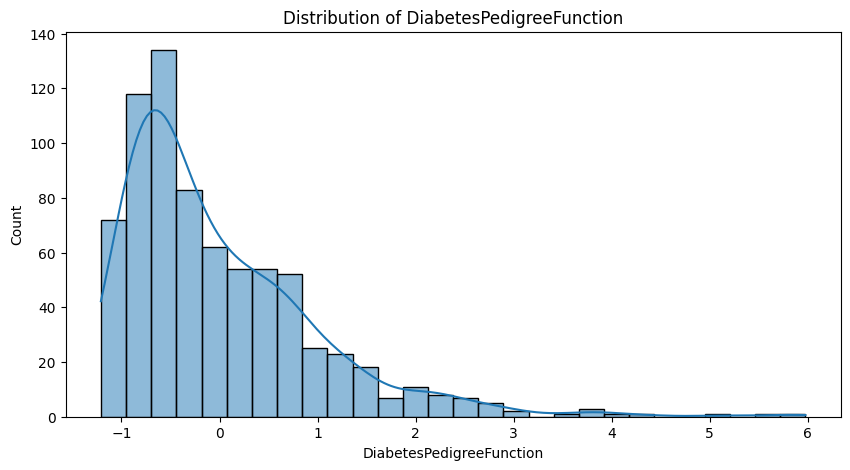

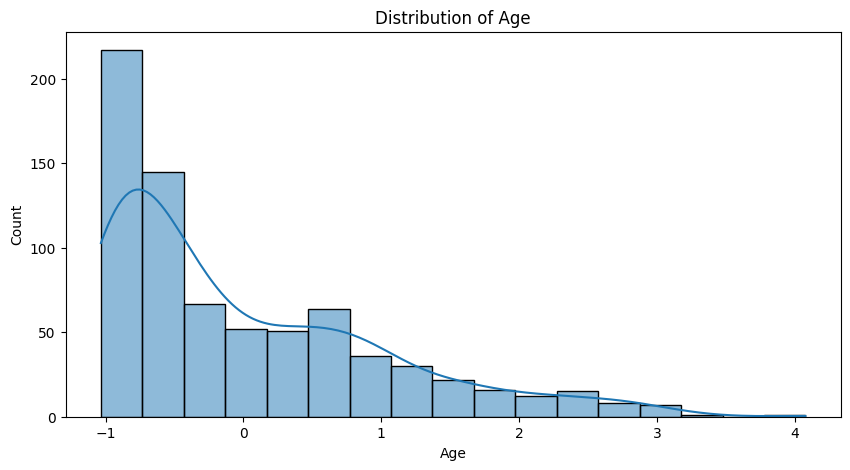

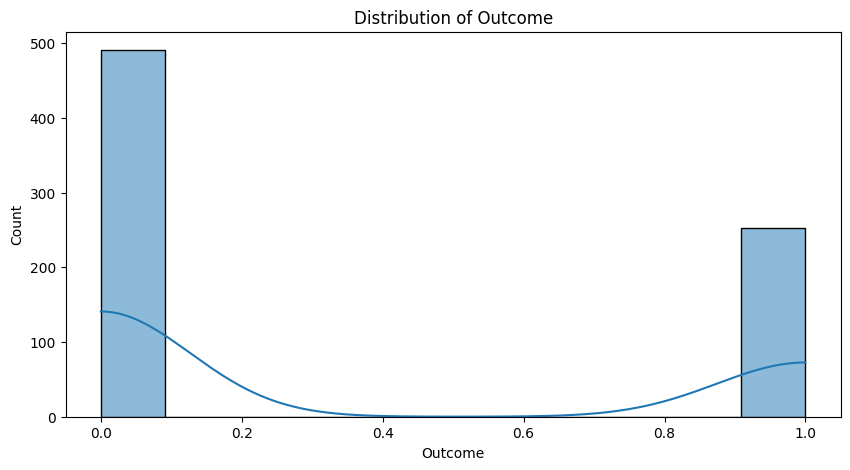

In [14]:
for column in data.columns:
    plt.figure(figsize=(10, 5))
    sns.histplot(data[column], kde=True)
    plt.title(f"Distribution of {column}")
    plt.show()

Applying the log transformation for the skewed data

In [15]:
data['Insulin'] = np.log1p(data['Insulin'])
data['DiabetesPedigreeFunction'] = np.log1p(data['DiabetesPedigreeFunction'])


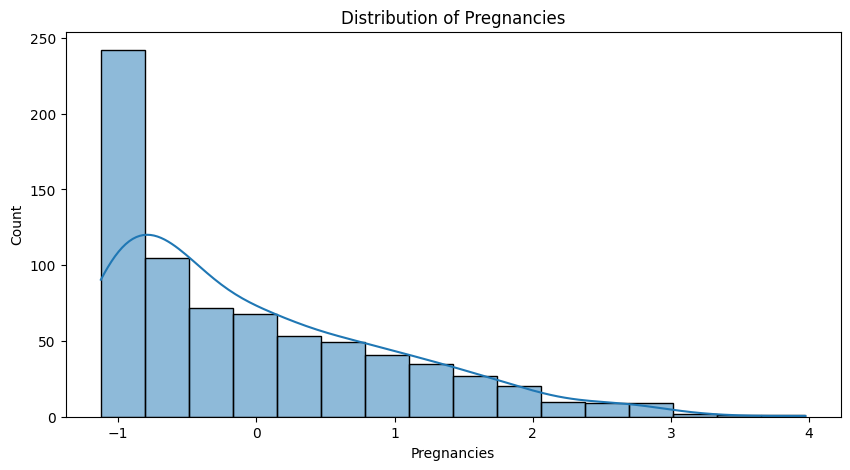

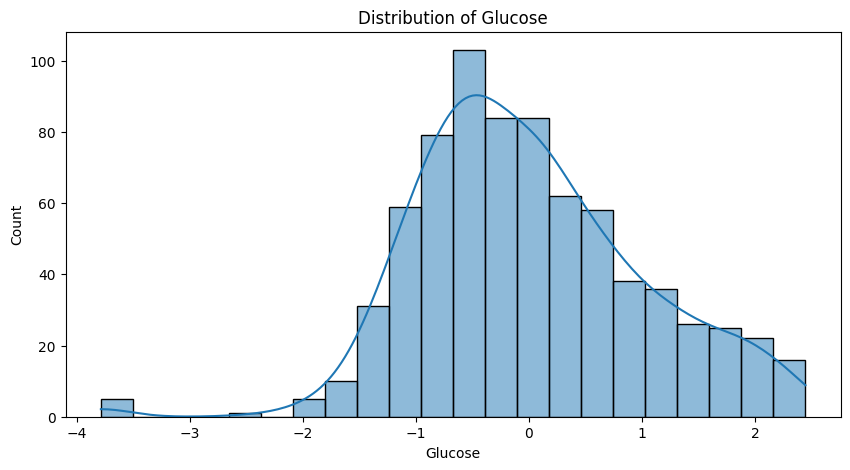

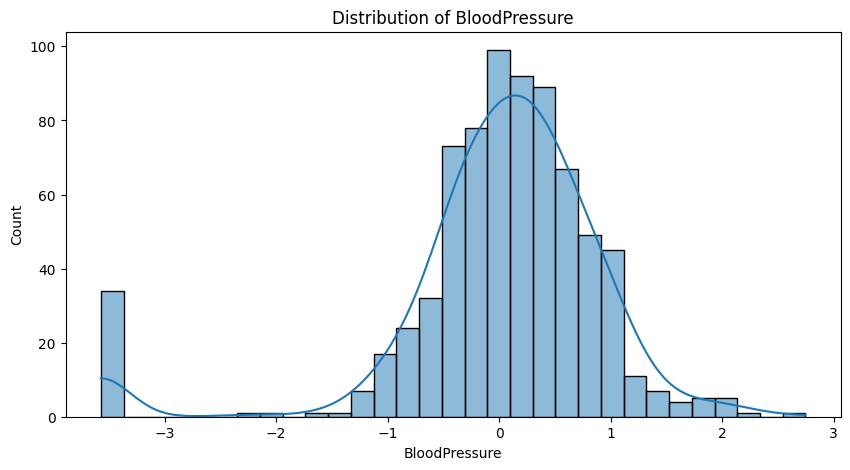

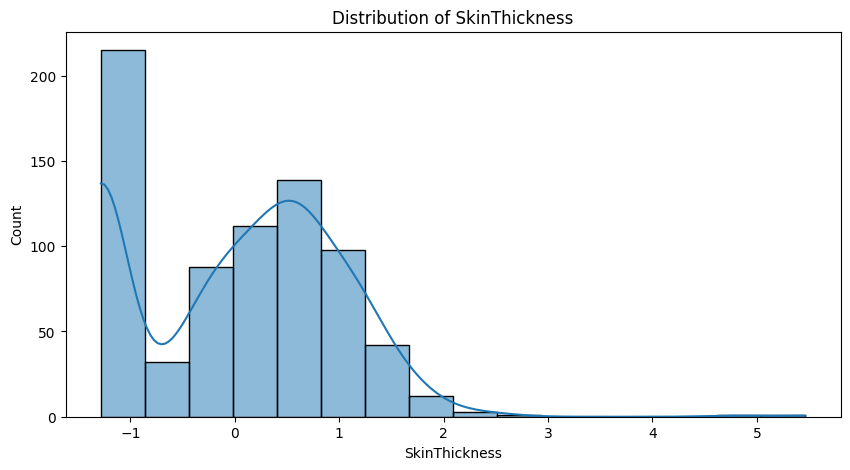

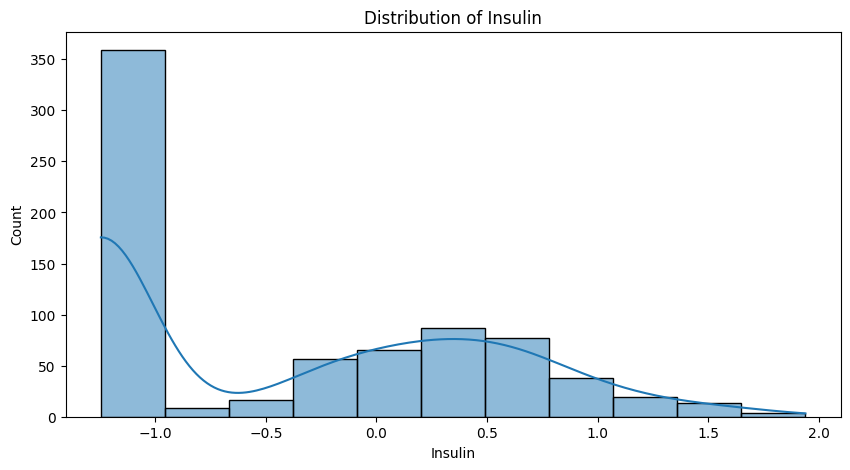

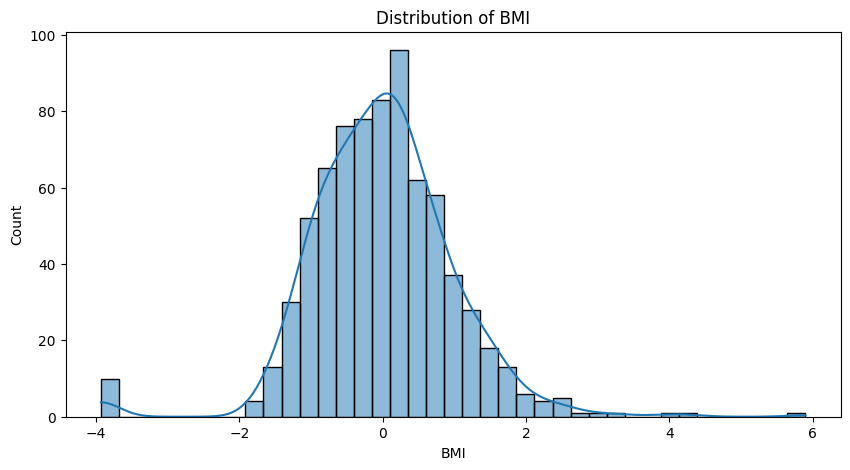

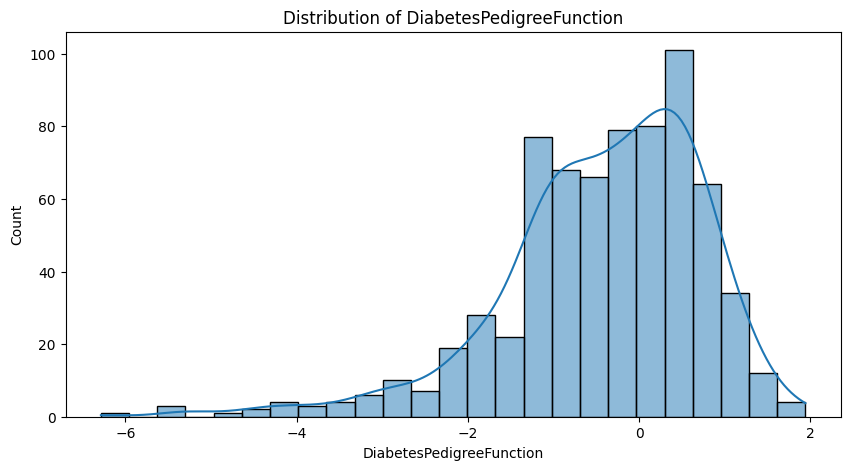

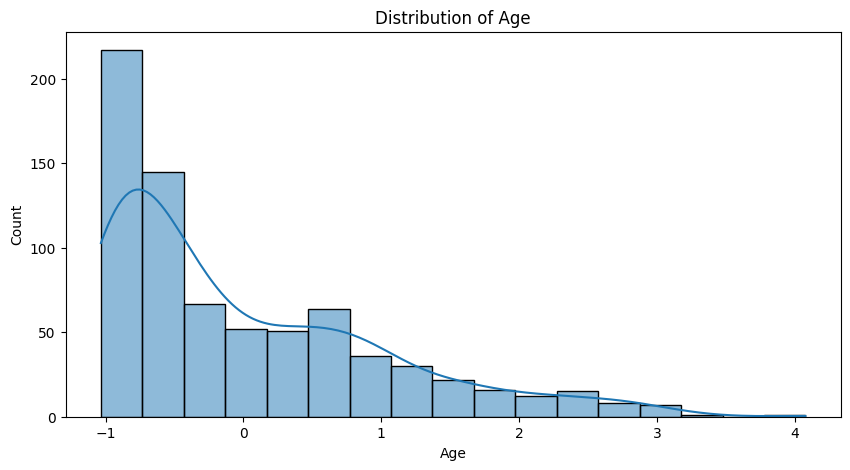

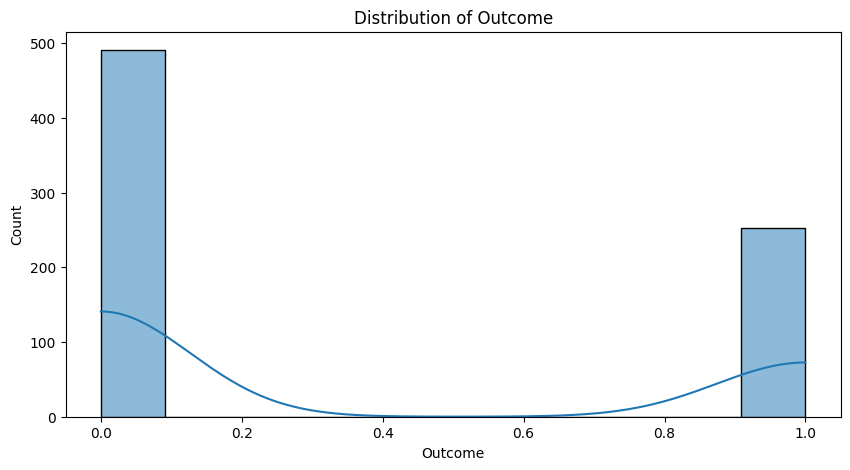

In [16]:
for column in data.columns:
    plt.figure(figsize=(10, 5))
    sns.histplot(data[column], kde=True)
    plt.title(f"Distribution of {column}")
    plt.show()

# **Spliting the data and applying oversampling**

In [17]:
!pip install imblearn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [18]:
from sklearn.model_selection import train_test_split
X = data.drop('Outcome', axis=1)
y = data['Outcome']

# 1. Split first
x_train, x_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [19]:
print(data.isnull().sum())

Pregnancies                  0
Glucose                      0
BloodPressure                0
SkinThickness                0
Insulin                      0
BMI                          0
DiabetesPedigreeFunction    49
Age                          0
Outcome                      0
dtype: int64


In [20]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')

x_train = imputer.fit_transform(x_train)
x_test = imputer.transform(x_test)

In [21]:
from imblearn.over_sampling import SMOTE


smote = SMOTE(random_state=42)
x_train, y_train = smote.fit_resample(x_train, y_train)

# **Train SVM model**

In [22]:
# train svm
from sklearn.svm import SVC
model = SVC(kernel='rbf', random_state=42)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

In [23]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7449664429530202


In [24]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.76      0.80        98
           1       0.61      0.73      0.66        51

    accuracy                           0.74       149
   macro avg       0.72      0.74      0.73       149
weighted avg       0.76      0.74      0.75       149

